  + AverageTemperature: 25.0
  + AverageTemperatureUncertainty: 0.5

Significa que la temperatura real ese mes probablemente estuvo entre 24.5°C y 25.5°C.

In [5]:
import numpy as np 
import pandas as pd

In [6]:
df = pd.read_csv('../data/GlobalLandTemperaturesByCity.csv')

In [7]:
df.rename(columns={'AverageTemperature': 'AvTemp', 'AverageTemperatureUncertainty': 'AvTempUn'}, inplace=True)
df

,dt,AvTemp,AvTempUn,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
...,...,...,...,...,...,...,...
8599207,2013-05-01,11.464,0.236,Zwolle,Netherlands,52.24N,5.26E
8599208,2013-06-01,15.043,0.261,Zwolle,Netherlands,52.24N,5.26E
8599209,2013-07-01,18.775,0.193,Zwolle,Netherlands,52.24N,5.26E
8599210,2013-08-01,18.025,0.298,Zwolle,Netherlands,52.24N,5.26E


In [8]:
df['dt'] = pd.to_datetime(df['dt'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8599212 entries, 0 to 8599211
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   dt         datetime64[ns]
 1   AvTemp     float64       
 2   AvTempUn   float64       
 3   City       object        
 4   Country    object        
 5   Latitude   object        
 6   Longitude  object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 459.2+ MB


In [9]:
borrar = (df['dt'] < '1950-01-01') & (df['AvTemp'].isna())
df = df[~borrar]
df

,dt,AvTemp,AvTempUn,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
5,1744-04-01,5.788,3.624,Århus,Denmark,57.05N,10.33E
6,1744-05-01,10.644,1.283,Århus,Denmark,57.05N,10.33E
7,1744-06-01,14.051,1.347,Århus,Denmark,57.05N,10.33E
8,1744-07-01,16.082,1.396,Århus,Denmark,57.05N,10.33E
...,...,...,...,...,...,...,...
8599207,2013-05-01,11.464,0.236,Zwolle,Netherlands,52.24N,5.26E
8599208,2013-06-01,15.043,0.261,Zwolle,Netherlands,52.24N,5.26E
8599209,2013-07-01,18.775,0.193,Zwolle,Netherlands,52.24N,5.26E
8599210,2013-08-01,18.025,0.298,Zwolle,Netherlands,52.24N,5.26E


In [10]:
df['numero'] = df['Latitude'].str.extract(r'([0-9]+\.[0-9]{2})').astype(float)
df['OrLat'] = df['Latitude'].str.extract(r'([NS])$')

C:\Users\detla\AppData\Local\Temp\ipykernel_8480\1537631586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['numero'] = df['Latitude'].str.extract(r'([0-9]+\.[0-9]{2})').astype(float)
C:\Users\detla\AppData\Local\Temp\ipykernel_8480\1537631586.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OrLat'] = df['Latitude'].str.extract(r'([NS])$')


In [11]:
df['Latitude'] = np.where(df['OrLat'] == 'S', -df['numero'], df['numero'])

C:\Users\detla\AppData\Local\Temp\ipykernel_8480\1216536586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Latitude'] = np.where(df['OrLat'] == 'S', -df['numero'], df['numero'])


In [12]:
df['numero'] = df['Longitude'].str.extract(r'([0-9]+\.[0-9]{2})').astype(float)
df['OrLon'] = df['Longitude'].str.extract(r'([EW])$')

C:\Users\detla\AppData\Local\Temp\ipykernel_8480\704299056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['numero'] = df['Longitude'].str.extract(r'([0-9]+\.[0-9]{2})').astype(float)
C:\Users\detla\AppData\Local\Temp\ipykernel_8480\704299056.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OrLon'] = df['Longitude'].str.extract(r'([EW])$')


In [13]:
df['Longitude'] = np.where(df['OrLon'] == 'W', -df['numero'], df['numero'])

C:\Users\detla\AppData\Local\Temp\ipykernel_8480\954906886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Longitude'] = np.where(df['OrLon'] == 'W', -df['numero'], df['numero'])


In [14]:
df['Longitude'] = np.where(df['OrLon'] == 'W', -df['numero'], df['numero'])

C:\Users\detla\AppData\Local\Temp\ipykernel_8480\954906886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Longitude'] = np.where(df['OrLon'] == 'W', -df['numero'], df['numero'])


In [15]:
df = df.drop(columns='numero')
df

,dt,AvTemp,AvTempUn,City,Country,Latitude,Longitude,OrLat,OrLon
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05,10.33,N,E
5,1744-04-01,5.788,3.624,Århus,Denmark,57.05,10.33,N,E
6,1744-05-01,10.644,1.283,Århus,Denmark,57.05,10.33,N,E
7,1744-06-01,14.051,1.347,Århus,Denmark,57.05,10.33,N,E
8,1744-07-01,16.082,1.396,Århus,Denmark,57.05,10.33,N,E
...,...,...,...,...,...,...,...,...,...
8599207,2013-05-01,11.464,0.236,Zwolle,Netherlands,52.24,5.26,N,E
8599208,2013-06-01,15.043,0.261,Zwolle,Netherlands,52.24,5.26,N,E
8599209,2013-07-01,18.775,0.193,Zwolle,Netherlands,52.24,5.26,N,E
8599210,2013-08-01,18.025,0.298,Zwolle,Netherlands,52.24,5.26,N,E


In [16]:
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month

In [17]:
def get_season(month):
    if month in [12, 1, 2]: return '0'
    elif month in [3, 4, 5]: return '1'
    elif month in [6, 7, 8]: return '2'
    else: return '3'

df['Season'] = df['Month'].apply(get_season)

In [18]:
df_annual_city = df.groupby(['City', 'Country', 'Year', 'Latitude', 'Longitude'])['AvTemp'].mean().reset_index()

In [19]:
df_annual_city

,City,Country,Year,Latitude,Longitude,AvTemp
0,A Coruña,Spain,1743,42.59,-8.73,10.779000
1,A Coruña,Spain,1744,42.59,-8.73,13.678125
2,A Coruña,Spain,1745,42.59,-8.73,9.170500
3,A Coruña,Spain,1750,42.59,-8.73,13.489273
4,A Coruña,Spain,1751,42.59,-8.73,13.698500
...,...,...,...,...,...,...
693244,Ürümqi,China,2009,44.20,87.20,7.287417
693245,Ürümqi,China,2010,44.20,87.20,6.650083
693246,Ürümqi,China,2011,44.20,87.20,6.806083
693247,Ürümqi,China,2012,44.20,87.20,6.600167


In [20]:
df_seasonal_means = df.groupby(['City', 'Year', 'Season'])['AvTemp'].mean().reset_index()

In [21]:
df_seasonal_pivot = df_seasonal_means.pivot_table(
    index=['City', 'Year'], 
    columns='Season', 
    values='AvTemp'
).reset_index()

In [22]:
df_seasonal_pivot.columns.name = None  # Eliminar el nombre del eje de columnas si existe
df_seasonal_pivot.rename(columns={
    '0': 'Avg_Winter_T',
    '1': 'Avg_Spring_T',
    '2': 'Avg_Summer_T',
    '3': 'Avg_Autumn_T'
}, inplace=True)

In [23]:
df_seasonal_pivot

,City,Year,Avg_Winter_T,Avg_Spring_T,Avg_Summer_T,Avg_Autumn_T
0,A Coruña,1743,NaN,NaN,NaN,10.779000
1,A Coruña,1744,8.798000,13.112500,17.201000,13.333333
2,A Coruña,1745,8.101500,10.239500,NaN,NaN
3,A Coruña,1750,8.836667,12.426333,18.586000,14.417500
4,A Coruña,1751,7.973000,11.286000,18.437000,15.759000
...,...,...,...,...,...,...
681564,Ürümqi,2009,-11.499333,10.228333,22.599667,7.821000
681565,Ürümqi,2010,-12.363333,6.480667,23.498333,8.984667
681566,Ürümqi,2011,-13.836000,8.324000,23.890333,8.846000
681567,Ürümqi,2012,-14.978333,10.593667,23.683333,7.102000


In [24]:
for col in ['Avg_Winter_T', 'Avg_Spring_T', 'Avg_Summer_T', 'Avg_Autumn_T']:
    df_seasonal_pivot[col] = df_seasonal_pivot.groupby('City')[col].transform(
        lambda x: x.fillna(x.rolling(window=3, min_periods=1, center=True).mean())
    )

In [25]:
df_annual_base = df.groupby(['City', 'Year'])['AvTemp'].mean().reset_index()
df_annual_base.rename(columns={'AvTemp': 'Avg_Annual_Temp'}, inplace=True)

In [47]:
df_annual_base

,City,Year,Avg_Annual_Temp
0,A Coruña,1743,10.779000
1,A Coruña,1744,13.678125
2,A Coruña,1745,9.170500
3,A Coruña,1750,13.489273
4,A Coruña,1751,13.698500
...,...,...,...
681564,Ürümqi,2009,7.287417
681565,Ürümqi,2010,6.650083
681566,Ürümqi,2011,6.806083
681567,Ürümqi,2012,6.600167


In [26]:
df_final = pd.merge(df_annual_base, df_seasonal_pivot, on=['City', 'Year'], how='left')

# Añadir también las coordenadas fijas por ciudad (para no perder Lat/Lon)
city_coords = df[['City', 'Country', 'Latitude', 'Longitude']].drop_duplicates()
df_final = pd.merge(df_final, city_coords, on='City', how='left')

In [27]:
df_final = df_final.sort_values(by=['City', 'Year']).reset_index(drop=True)

In [28]:
df_final['Dist_to_Pole'] = 90 - df_final['Latitude'].abs()
df_final

,City,Year,Avg_Annual_Temp,Avg_Winter_T,Avg_Spring_T,Avg_Summer_T,Avg_Autumn_T,Country,Latitude,Longitude,Dist_to_Pole
0,A Coruña,1743,10.779000,8.798000,13.112500,17.201000,10.779000,Spain,42.59,-8.73,47.41
1,A Coruña,1744,13.678125,8.798000,13.112500,17.201000,13.333333,Spain,42.59,-8.73,47.41
2,A Coruña,1745,9.170500,8.101500,10.239500,17.893500,13.875417,Spain,42.59,-8.73,47.41
3,A Coruña,1750,13.489273,8.836667,12.426333,18.586000,14.417500,Spain,42.59,-8.73,47.41
4,A Coruña,1751,13.698500,7.973000,11.286000,18.437000,15.759000,Spain,42.59,-8.73,47.41
...,...,...,...,...,...,...,...,...,...,...,...
695458,Ürümqi,2009,7.287417,-11.499333,10.228333,22.599667,7.821000,China,44.20,87.20,45.80
695459,Ürümqi,2010,6.650083,-12.363333,6.480667,23.498333,8.984667,China,44.20,87.20,45.80
695460,Ürümqi,2011,6.806083,-13.836000,8.324000,23.890333,8.846000,China,44.20,87.20,45.80
695461,Ürümqi,2012,6.600167,-14.978333,10.593667,23.683333,7.102000,China,44.20,87.20,45.80


In [29]:
city_historical_means = df_final.groupby('City')['Avg_Annual_Temp'].transform('mean')
df_final['Temp_Anomaly'] = df_final['Avg_Annual_Temp'] - city_historical_means

In [30]:
df_final['Seasonal_Range'] = df_final['Avg_Summer_T'] - df_final['Avg_Winter_T']

In [31]:
df_final

,City,Year,Avg_Annual_Temp,Avg_Winter_T,Avg_Spring_T,Avg_Summer_T,Avg_Autumn_T,Country,Latitude,Longitude,Dist_to_Pole,Temp_Anomaly,Seasonal_Range
0,A Coruña,1743,10.779000,8.798000,13.112500,17.201000,10.779000,Spain,42.59,-8.73,47.41,-2.348270,8.403000
1,A Coruña,1744,13.678125,8.798000,13.112500,17.201000,13.333333,Spain,42.59,-8.73,47.41,0.550855,8.403000
2,A Coruña,1745,9.170500,8.101500,10.239500,17.893500,13.875417,Spain,42.59,-8.73,47.41,-3.956770,9.792000
3,A Coruña,1750,13.489273,8.836667,12.426333,18.586000,14.417500,Spain,42.59,-8.73,47.41,0.362003,9.749333
4,A Coruña,1751,13.698500,7.973000,11.286000,18.437000,15.759000,Spain,42.59,-8.73,47.41,0.571230,10.464000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
695458,Ürümqi,2009,7.287417,-11.499333,10.228333,22.599667,7.821000,China,44.20,87.20,45.80,1.355847,34.099000
695459,Ürümqi,2010,6.650083,-12.363333,6.480667,23.498333,8.984667,China,44.20,87.20,45.80,0.718513,35.861667
695460,Ürümqi,2011,6.806083,-13.836000,8.324000,23.890333,8.846000,China,44.20,87.20,45.80,0.874513,37.726333
695461,Ürümqi,2012,6.600167,-14.978333,10.593667,23.683333,7.102000,China,44.20,87.20,45.80,0.668597,38.661667


In [34]:
print(df_final.isnull().sum())

City                0
Year                0
Avg_Annual_Temp     0
Avg_Winter_T       13
Avg_Spring_T       40
Avg_Summer_T       79
Avg_Autumn_T       27
Country             0
Latitude            0
Longitude           0
Dist_to_Pole        0
Temp_Anomaly        0
Seasonal_Range     86
dtype: int64


In [45]:
df_final[df_final.isnull().any(axis=1)]

,City,Year,Avg_Annual_Temp,Avg_Winter_T,Avg_Spring_T,Avg_Summer_T,Avg_Autumn_T,Country,Latitude,Longitude,Dist_to_Pole,Temp_Anomaly,Seasonal_Range
949,Abadan,1820,32.877000,13.9370,NaN,32.877000,19.968000,Iran,29.74,48.00,60.26,7.891572,18.940000
950,Abadan,1821,22.599000,13.9370,NaN,33.892000,19.968000,Iran,29.74,48.00,60.26,-2.386428,19.955000
3523,Acapulco,1843,24.008000,NaN,24.008000,26.793000,NaN,Mexico,16.87,-100.47,73.13,-2.148223,NaN
4616,Acuña,1823,27.129250,NaN,NaN,28.330000,23.527000,Mexico,29.74,-101.54,60.26,7.617497,NaN
6324,Agadir,1787,18.250125,14.0765,17.372333,21.910333,NaN,Morocco,29.74,-9.23,60.26,0.765278,7.833833
...,...,...,...,...,...,...,...,...,...,...,...,...,...
661601,Westminster,1775,10.316000,-0.5080,10.204000,NaN,10.390667,United States,39.38,-104.05,50.62,1.538502,NaN
668498,Xalapa,1826,15.448000,15.4480,NaN,23.478000,NaN,Mexico,20.09,-97.25,69.91,-4.744275,8.030000
668499,Xalapa,1827,23.478000,15.4480,NaN,23.478000,19.980000,Mexico,20.09,-97.25,69.91,3.285725,8.030000
674944,Yao,1841,13.897500,5.1910,13.897500,NaN,16.175000,Japan,34.56,136.22,55.44,-0.850686,NaN


In [46]:
df_final[df_final.isnull().any(axis=1)][df_final['City'] == 'Abadan']

C:\Users\detla\AppData\Local\Temp\ipykernel_8480\93224601.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_final[df_final.isnull().any(axis=1)][df_final['City'] == 'Abadan']


,City,Year,Avg_Annual_Temp,Avg_Winter_T,Avg_Spring_T,Avg_Summer_T,Avg_Autumn_T,Country,Latitude,Longitude,Dist_to_Pole,Temp_Anomaly,Seasonal_Range
949,Abadan,1820,32.877,13.937,NaN,32.877,19.968,Iran,29.74,48.0,60.26,7.891572,18.940
950,Abadan,1821,22.599,13.937,NaN,33.892,19.968,Iran,29.74,48.0,60.26,-2.386428,19.955


In [32]:
df_final

,City,Year,Avg_Annual_Temp,Avg_Winter_T,Avg_Spring_T,Avg_Summer_T,Avg_Autumn_T,Country,Latitude,Longitude,Dist_to_Pole,Temp_Anomaly,Seasonal_Range
0,A Coruña,1743,10.779000,8.798000,13.112500,17.201000,10.779000,Spain,42.59,-8.73,47.41,-2.348270,8.403000
1,A Coruña,1744,13.678125,8.798000,13.112500,17.201000,13.333333,Spain,42.59,-8.73,47.41,0.550855,8.403000
2,A Coruña,1745,9.170500,8.101500,10.239500,17.893500,13.875417,Spain,42.59,-8.73,47.41,-3.956770,9.792000
3,A Coruña,1750,13.489273,8.836667,12.426333,18.586000,14.417500,Spain,42.59,-8.73,47.41,0.362003,9.749333
4,A Coruña,1751,13.698500,7.973000,11.286000,18.437000,15.759000,Spain,42.59,-8.73,47.41,0.571230,10.464000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
695458,Ürümqi,2009,7.287417,-11.499333,10.228333,22.599667,7.821000,China,44.20,87.20,45.80,1.355847,34.099000
695459,Ürümqi,2010,6.650083,-12.363333,6.480667,23.498333,8.984667,China,44.20,87.20,45.80,0.718513,35.861667
695460,Ürümqi,2011,6.806083,-13.836000,8.324000,23.890333,8.846000,China,44.20,87.20,45.80,0.874513,37.726333
695461,Ürümqi,2012,6.600167,-14.978333,10.593667,23.683333,7.102000,China,44.20,87.20,45.80,0.668597,38.661667


### 📋 Muestra

,City,Year,Avg_Annual_Temp,Avg_Winter_T,Avg_Spring_T,Avg_Summer_T,Avg_Autumn_T,Country,Latitude,Longitude,Dist_to_Pole,Temp_Anomaly,Seasonal_Range
0,A Coruña,1743,10.779000,8.798000,13.112500,17.2010,10.779000,Spain,42.59,-8.73,47.41,-2.348270,8.403000
1,A Coruña,1744,13.678125,8.798000,13.112500,17.2010,13.333333,Spain,42.59,-8.73,47.41,0.550855,8.403000
2,A Coruña,1745,9.170500,8.101500,10.239500,17.8935,13.875417,Spain,42.59,-8.73,47.41,-3.956770,9.792000
3,A Coruña,1750,13.489273,8.836667,12.426333,18.5860,14.417500,Spain,42.59,-8.73,47.41,0.362003,9.749333
4,A Coruña,1751,13.698500,7.973000,11.286000,18.4370,15.759000,Spain,42.59,-8.73,47.41,0.571230,10.464000


### 📊 Info → `695,332` filas × `13` columnas

<class 'pandas.core.frame.DataFrame'>
Index: 695332 entries, 0 to 695462
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   City             695332 non-null  object 
 1   Year             695332 non-null  int32  
 2   Avg_Annual_Temp  695332 non-null  float64
 3   Avg_Winter_T     695332 non-null  float64
 4   Avg_Spring_T     695332 non-null  float64
 5   Avg_Summer_T     695332 non-null  float64
 6   Avg_Autumn_T     695332 non-null  float64
 7   Country          695332 non-null  object 
 8   Latitude         695332 non-null  float64
 9   Longitude        695332 non-null  float64
 10  Dist_to_Pole     695332 non-null  float64
 11  Temp_Anomaly     695332 non-null  float64
 12  Seasonal_Range   695332 non-null  float64
dtypes: float64(10), int32(1), object(2)
memory usage: 71.6+ MB
None


#### Uniques

City                 3448
Year                  267
Avg_Annual_Temp    203776
Avg_Winter_T       154434
Avg_Spring_T       133314
Avg_Summer_T       100588
Avg_Autumn_T       122026
Country               159
Latitude               73
Longitude            1227
Dist_to_Pole           43
Temp_Anomaly       274628
Seasonal_Range     195883
dtype: int64


### ⚠️ Null & NaN

City               0
Year               0
Avg_Annual_Temp    0
Avg_Winter_T       0
Avg_Spring_T       0
Avg_Summer_T       0
Avg_Autumn_T       0
Country            0
Latitude           0
Longitude          0
Dist_to_Pole       0
Temp_Anomaly       0
Seasonal_Range     0
dtype: int64


### 📦 Describe

,Year,Avg_Annual_Temp,Avg_Winter_T,Avg_Spring_T,Avg_Summer_T,Avg_Autumn_T,Latitude,Longitude,Dist_to_Pole,Temp_Anomaly,Seasonal_Range
count,695332.000,695332.000,695332.000,695332.000,695332.000,695332.000,695332.000,695332.000,695332.000,695332.000,695332.000
mean,1909.773,16.703,10.067,16.930,22.651,17.215,26.066,29.870,58.848,0.000,12.584
std,65.109,7.862,12.248,8.719,5.348,7.603,22.798,72.443,15.124,0.856,11.124
min,1743.000,-17.833,-36.701,-20.209,-2.215,-17.180,-52.240,-151.130,20.080,-20.014,-17.494
25%,1863.000,9.888,0.870,9.380,18.411,10.632,13.660,-5.260,47.410,-0.400,2.705
50%,1914.000,16.735,10.520,16.179,23.329,17.745,31.350,31.380,57.050,-0.004,14.066
75%,1964.000,24.676,21.982,25.633,26.784,24.502,42.590,88.250,69.910,0.418,20.555
max,2013.000,32.333,30.214,34.500,38.236,31.883,69.920,176.950,89.200,14.219,49.134


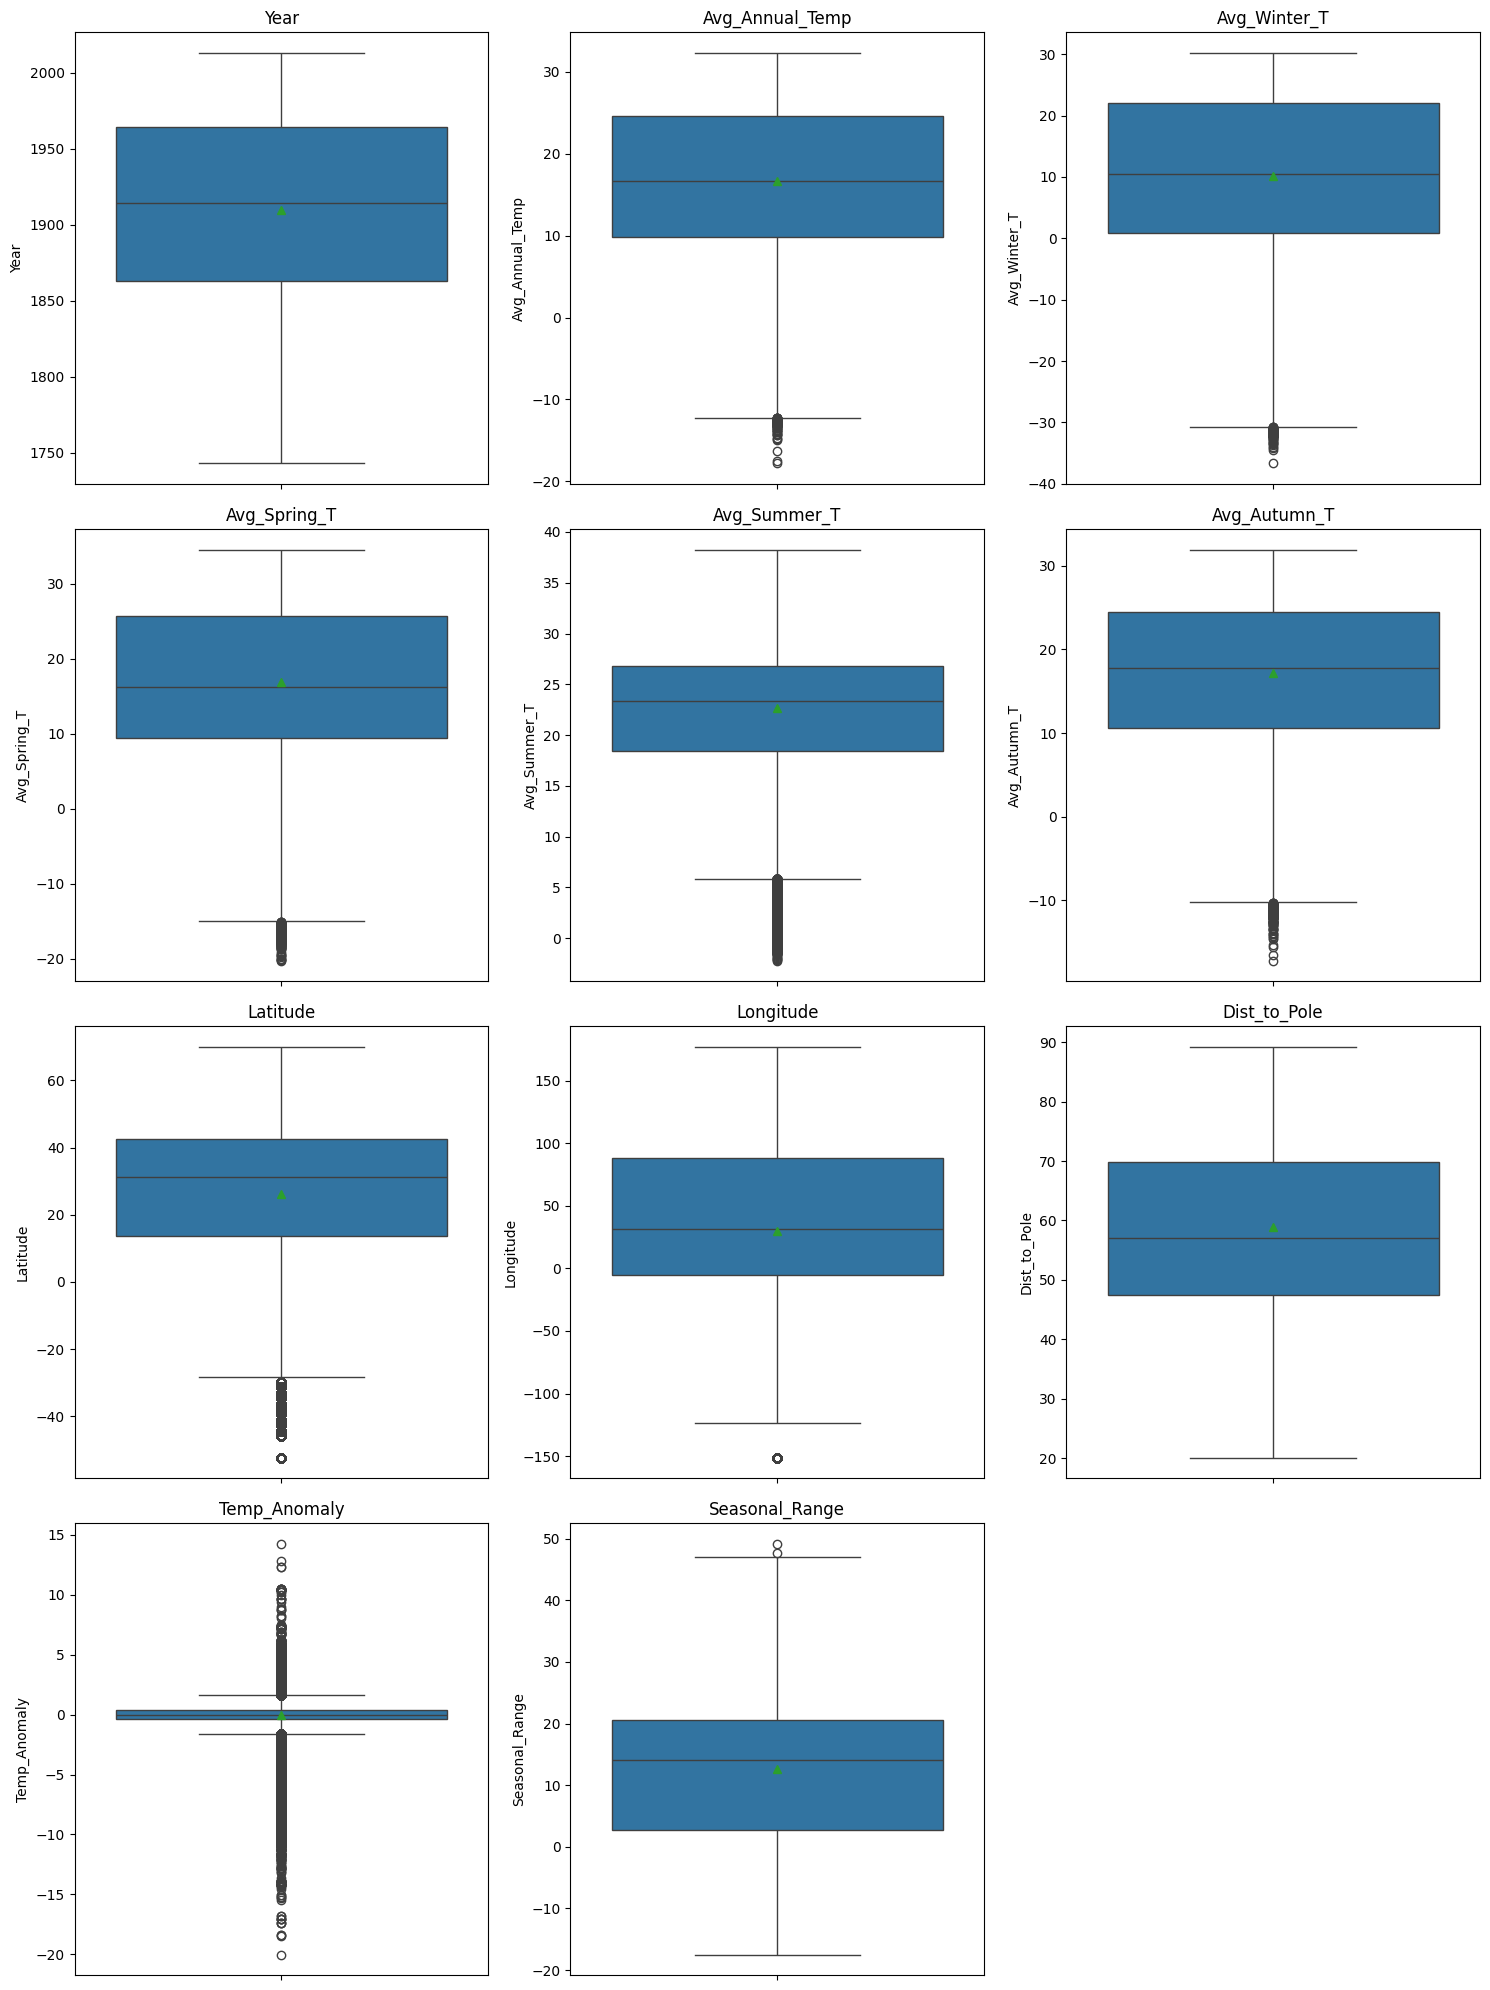

### 📈 Comparación

### (target: Avg_Annual_Temp)

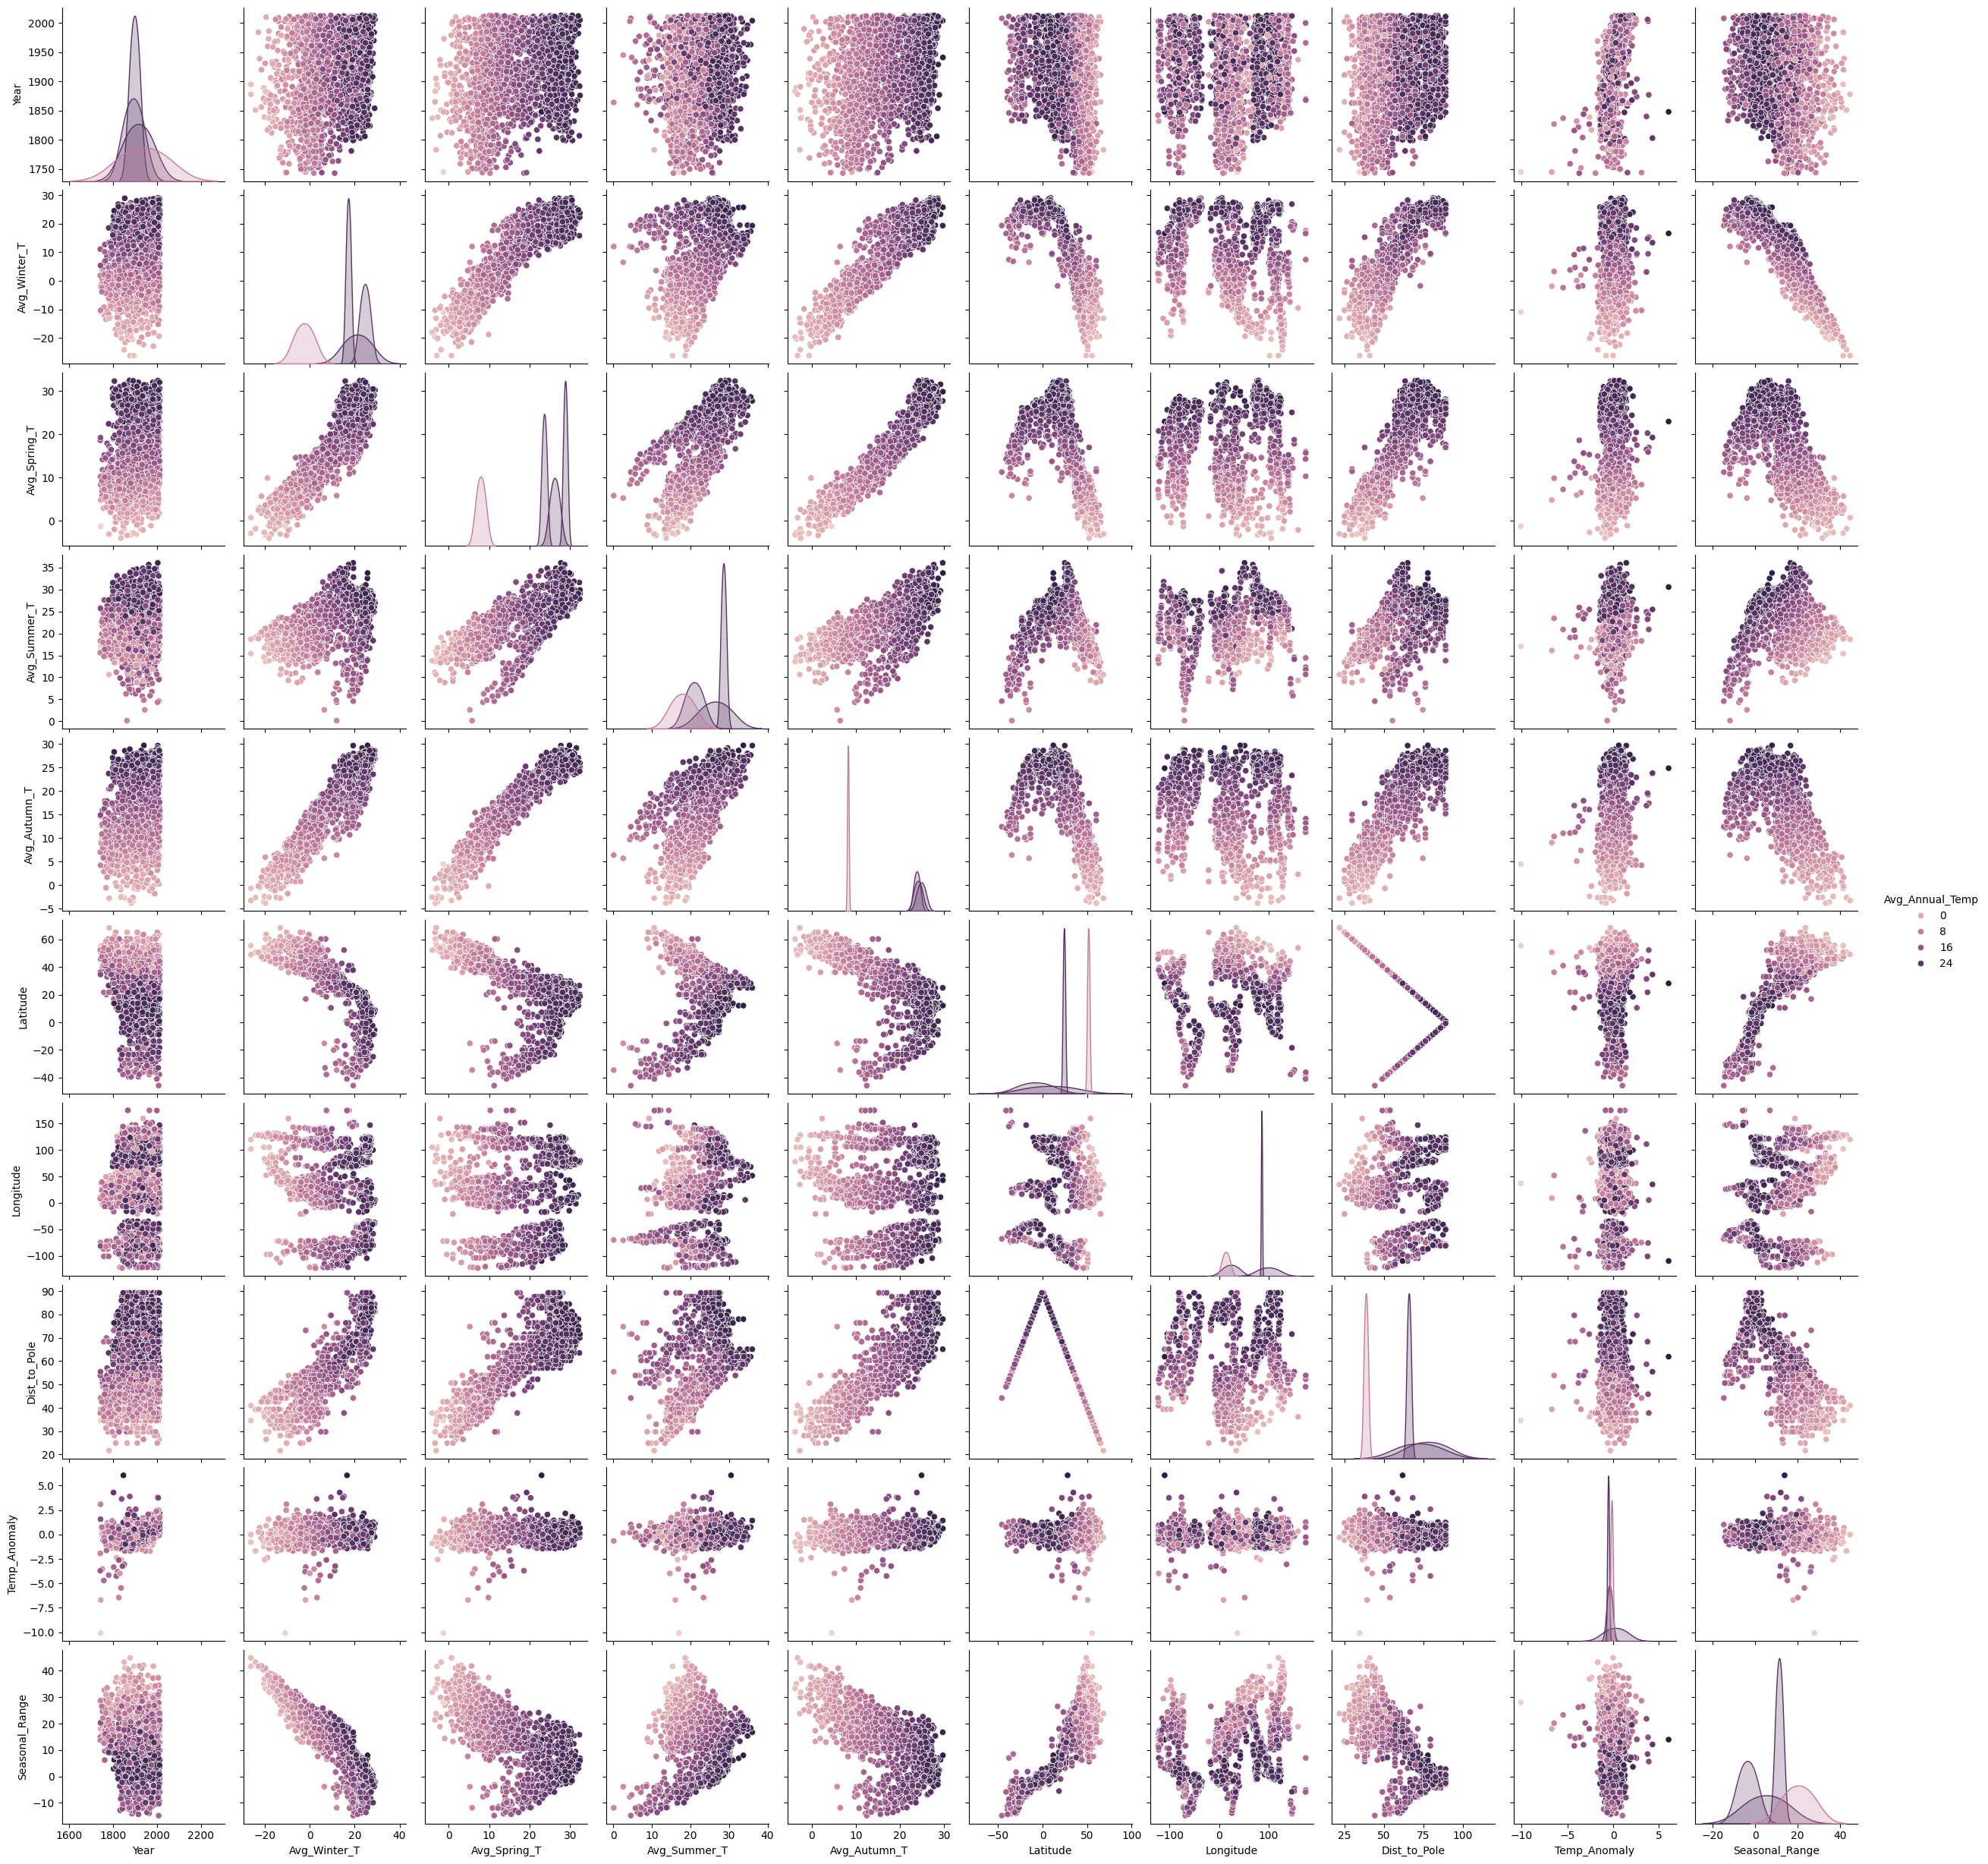

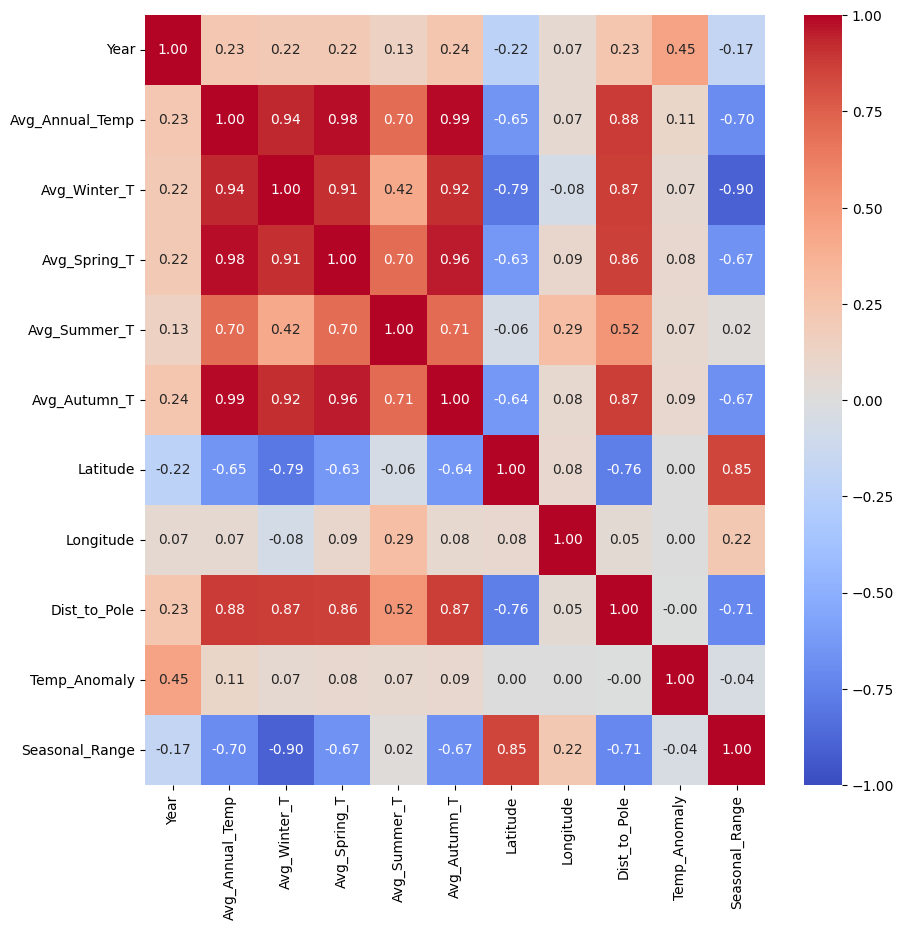

In [ ]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def eda(df, target=None):
    """
        Realiza un EDA automático visual.
    """
    
    # 1. MUESTRA
    print('='*100)
    display(Markdown("### 📋 Muestra"))
    display(df.head()) # Head es suficiente y más rápido
    
    # 2. INFO
    print('='*100)
    display(Markdown(f"### 📊 Info → `{df.shape[0]:,}` filas × `{df.shape[1]}` columnas"))
    # df.info() puede ser muy lento en consola, mejor mostrar dtypes resumidos si es gigante
    # Pero lo dejo como pediste:
    print(df.info())
    display(Markdown('#### Uniques'))
    print(df.nunique())
    
    # 3. NULOS
    print('='*100)
    display(Markdown("### ⚠️ Null & NaN"))
    print(df.isna().sum())
    # Mostrar solo las filas con nulos si no son demasiadas, para no colgar el notebook
    null_rows = df[df.isnull().any(axis=1)]
    if len(null_rows) > 0:
        display(null_rows.head())
    
    # 4. BOXPLOTS (Solo numéricas)
    print('='*100)
    display(Markdown("### 📦 Describe"))
    display(df.describe().round(3))
    
    cols = df.describe().columns
    n = len(cols)

    if n > 0:
        # Crear rejilla
        fig, axes = plt.subplots(nrows=(n//3)+1, ncols=3, figsize=(15, 5*((n//3)+1)))
        axes = axes.flatten()

        for i, col in enumerate(cols):
            sns.boxplot(y=df[col], ax=axes[i], showmeans=True)
            axes[i].set_title(col)

        # Limpiar gráficos vacíos sobrantes
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
            
        plt.tight_layout()
        plt.show()
    
    # 5. PAIRPLOT
    print('='*100)
    display(Markdown(f"### 📈 Comparación"))
    
    df_for_plot = df.sample(min(2000, len(df))) if len(df) > 2000 else df

    if target is not None:
        t_name = target.name if hasattr(target, 'name') else target
        display(Markdown(f"### (target: {t_name})"))
        
        if t_name not in df_for_plot.columns:
            # CAMBIO CLAVE: .copy() para evitar SettingWithCopyWarning y alineación lenta
            df_plot = df_for_plot[cols].copy()
            df_plot[t_name] = target.loc[df_plot.index] if hasattr(target, 'loc') else target
        else:
            df_plot = df_for_plot[cols]

        # Si el target no está en cols, lo añadimos al plot manualmente si es necesario
        if t_name not in df_plot.columns:
             df_plot[t_name] = df_for_plot[t_name]

        sns.pairplot(df_plot, hue=t_name)
        plt.show()
        
    else:
        sns.pairplot(df_for_plot)
        plt.show()
        
    # HEATMAP
    if n > 1:
        plt.figure(figsize=(10, 10)) 
        # CAMBIO CLAVE: fmt='.2f' es correcto para correlaciones (-1 a 1). '.1%' da error.
        sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, cmap="coolwarm")
        plt.show()
        
eda(df_final, df_final['Avg_Annual_Temp'])

In [ ]:
# climaDS.to_csv('../data/tiempoDS.csv.gz', index=False, compression='gzip')